# 3D CNN Models - Hand Gesture Recognition

Two models trained directly on raw-pixel video clips from `03_clip_extraction.ipynb`:
1. **Model A** - a compact 3D CNN (Conv3D stack) trained from scratch
2. **Model B** - pretrained R(2+1)D-18 (Kinetics-400), fine-tuned

Both are evaluated with the shared `src/evaluation/metrics.py` module so results are
directly comparable to the landmark-based branche.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.dataset import GESTURE_NAMES, NUM_CLASSES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.video_dataset import (
    GestureClipDataset, stratified_train_val_split, compute_class_weights,
    IMAGENET_MEAN, IMAGENET_STD, KINETICS_MEAN, KINETICS_STD,
)
from src.models.train_utils import get_device
from src.models.train_utils import train_model, plot_history, predict

CLIP_DIR = "../data/processed"

DEVICE = get_device()  # MPS > CUDA > CPU
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Dataset & DataLoader

Stratified train/val split carved out of the train metadata only (test stays untouched,
official split). 

Class weights are computed from the train split for the weighted loss.

In [2]:
train_df, val_df = stratified_train_val_split(
    f"{CLIP_DIR}/train/_metadata.csv", val_frac=0.15, seed=42
)
print(f"Train: {len(train_df)}   Val: {len(val_df)}")

class_weights = compute_class_weights(train_df, num_classes=NUM_CLASSES)
print("\nClass weights (balanced: N / (num_classes * count)):")
for name, w in zip(GESTURE_NAMES, class_weights):
    print(f"  {name:14s} {w:.3f}")

Train: 2649   Val: 468

Class weights (balanced: N / (num_classes * count)):
  Point-1f       0.322
  Point-2f       0.323
  Click-1f       1.617
  Click-2f       1.617
  Throw-up       1.617
  Throw-down     1.617
  Throw-left     1.617
  Throw-right    1.617
  Open-twice     1.617
  DblClick-1f    1.630
  DblClick-2f    1.617
  Zoom-in        1.617
  Zoom-out       1.617


In [3]:
BATCH_SIZE = 8

# ImageNet stats for the from-scratch model (Model B will use its own
# Kinetics-normalized loaders).
train_ds = GestureClipDataset(train_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=True)
val_ds = GestureClipDataset(val_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)
test_ds = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")

Train batches: 332   Val batches: 59   Test batches: 138


## 2. Sanity check - inspect a batch

In [4]:
clips, labels = next(iter(train_loader))
print(f"Batch clips shape:  {clips.shape}")   # expect (B, 3, 16, 112, 112)
print(f"Batch labels shape: {labels.shape}")
print(f"dtype: {clips.dtype}, value range: [{clips.min():.3f}, {clips.max():.3f}]")
print(f"Labels: {labels.tolist()}")

Batch clips shape:  torch.Size([8, 3, 16, 112, 112])
Batch labels shape: torch.Size([8])
dtype: torch.float32, value range: [-2.118, 2.640]
Labels: [1, 0, 10, 11, 8, 1, 1, 8]


## 3. Visualize a clip - raw vs. augmented

Confirms the augmentation pipeline (flip / crop jitter / temporal jitter / color jitter)
is doing something reasonable.

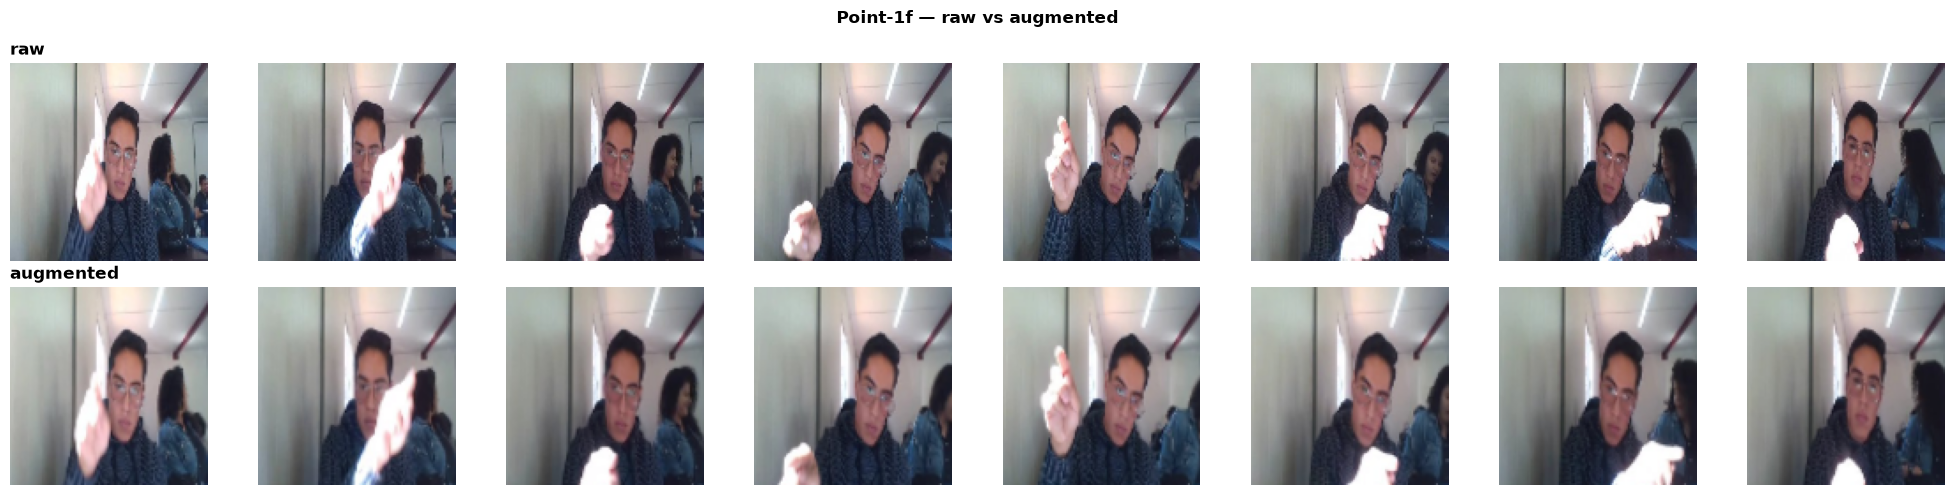

In [5]:
def denormalize(clip_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """(3, T, H, W) normalized tensor -> (T, H, W, 3) uint8 for display."""
    clip = clip_tensor.numpy() * std.reshape(3, 1, 1, 1) + mean.reshape(3, 1, 1, 1)
    clip = np.clip(clip, 0, 1)
    clip = np.transpose(clip, (1, 2, 3, 0))  # (T, H, W, 3)
    return (clip * 255).astype(np.uint8)


idx = 0
raw_clip = np.load(train_df.iloc[idx]['npy_path'])
aug_clip_t, label = train_ds[idx]
aug_clip = denormalize(aug_clip_t)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(raw_clip[i * 2]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_clip[i * 2]); axes[1, i].axis('off')
axes[0, 0].set_title("raw", loc='left', fontweight='bold')
axes[1, 0].set_title("augmented", loc='left', fontweight='bold')
plt.suptitle(f"{train_df.iloc[idx]['gesture_name']} — raw vs augmented", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model A - 3D CNN from scratch

A compact Conv3D stack, kept small so it trains in reasonable time on MPS:

```
(3,16,112,112) → Conv3D(3→32)  + BN + ReLU + MaxPool3D(2)
               → Conv3D(32→64) + BN + ReLU + MaxPool3D(2)
               → Conv3D(64→128)+ BN + ReLU + MaxPool3D(2)
               → Conv3D(128→256)+BN + ReLU + AdaptiveAvgPool3D(1)
               → FC(256→128) + ReLU + Dropout(0.5) → FC(128→13)
```

In [6]:
from src.models.cnn3d import Simple3DCNN

model_a = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model_a.parameters())
n_trainable = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A parameters: {n_params:,} total, {n_trainable:,} trainable")

# Forward-pass sanity check on a real batch, on-device.
clips, labels = next(iter(train_loader))
with torch.no_grad():
    logits = model_a(clips.to(DEVICE))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {logits.shape}")   # expect (B, 13)

Model A parameters: 1,199,821 total, 1,199,821 trainable
Input shape:  torch.Size([8, 3, 16, 112, 112])
Output shape: torch.Size([8, 13])


## Note on training environment
 
The learning-rate sweep and final training for both models were run on **Kaggle
(GPU)** rather than locally. 

**Speed** - each epoch of the from-scratch 3D CNN took ~270 s on the local
   Mac (MPS), making a full sweep impractical. On a Kaggle GPU an epoch is ~35 s.

The cells that follow load the results produced on Kaggle (saved under `results/kaggleA/` and
`results/kaggleB/`) and evaluate them with the shared `full_evaluation`.
The notebooks that ran on Keggle are in `notebooks/07_1_kaggle_model3DCNN.ipynb` and `notebooks/07_2_Kaggle_modelsR(2+1)D.ipynb`

## 4a. Load Kaggle Model A results and evaluate

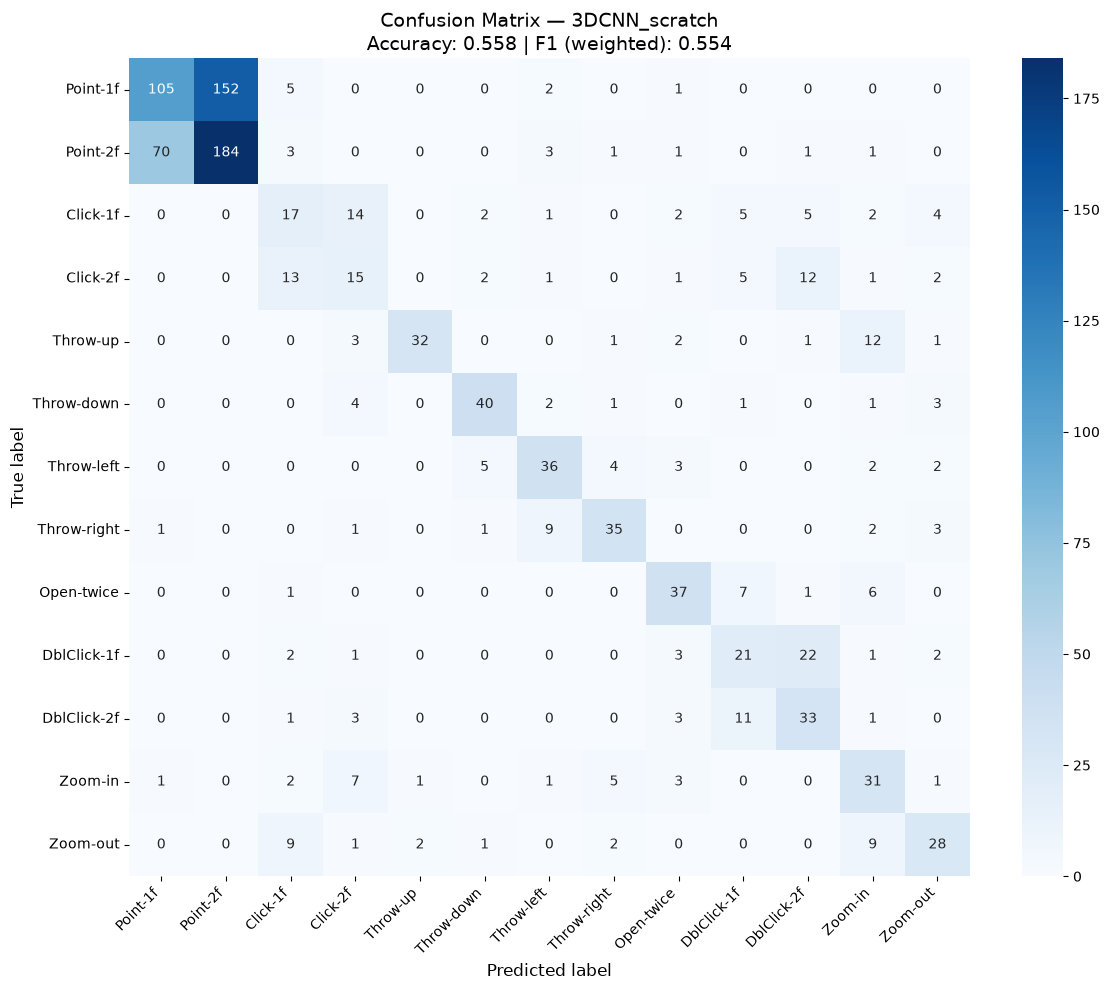

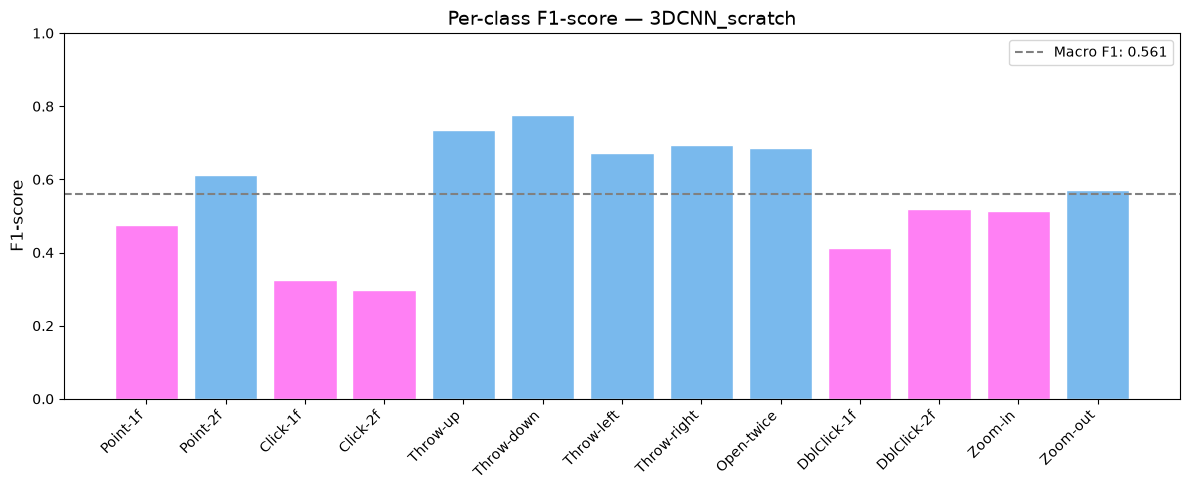


  3DCNN_scratch — Results
  Accuracy:          0.5577
  F1 (weighted):     0.5542
  F1 (macro):        0.5606
  Precision (w):     0.5704
  Recall (w):        0.5577
  Top-3 Accuracy:    0.9101
  Top-5 Accuracy:    0.9619

              precision    recall  f1-score   support

    Point-1f       0.59      0.40      0.48       265
    Point-2f       0.55      0.70      0.61       264
    Click-1f       0.32      0.33      0.32        52
    Click-2f       0.31      0.29      0.30        52
    Throw-up       0.91      0.62      0.74        52
  Throw-down       0.78      0.77      0.78        52
  Throw-left       0.65      0.69      0.67        52
 Throw-right       0.71      0.67      0.69        52
  Open-twice       0.66      0.71      0.69        52
 DblClick-1f       0.42      0.40      0.41        52
 DblClick-2f       0.44      0.63      0.52        52
     Zoom-in       0.45      0.60      0.51        52
    Zoom-out       0.61      0.54      0.57        52

    accuracy      

In [7]:
# Load predictions produced on Kaggle (sweep + training to saturation)
dataA = np.load("../results/kaggleA/predictions_modelA.npz")
y_true_a, y_pred_a, y_prob_a = dataA['y_true'], dataA['y_pred'], dataA['y_prob']
 
results_a = full_evaluation(
    y_true_a, y_pred_a, "3DCNN_scratch",
    save_dir="../results/figures", y_prob=y_prob_a
)
 
# Load the saved summary (accuracy, best_lr, config, ...)
with open("../results/kaggleA/3dcnn_scratch_results.json") as f:
    summary_a = json.load(f)
print("\nModel A summary (from Kaggle):")
print(json.dumps(summary_a, indent=2))

## 4b.  Kaggle training curves and sweep plots for Model A

Learning-rate sweep (to saturation):


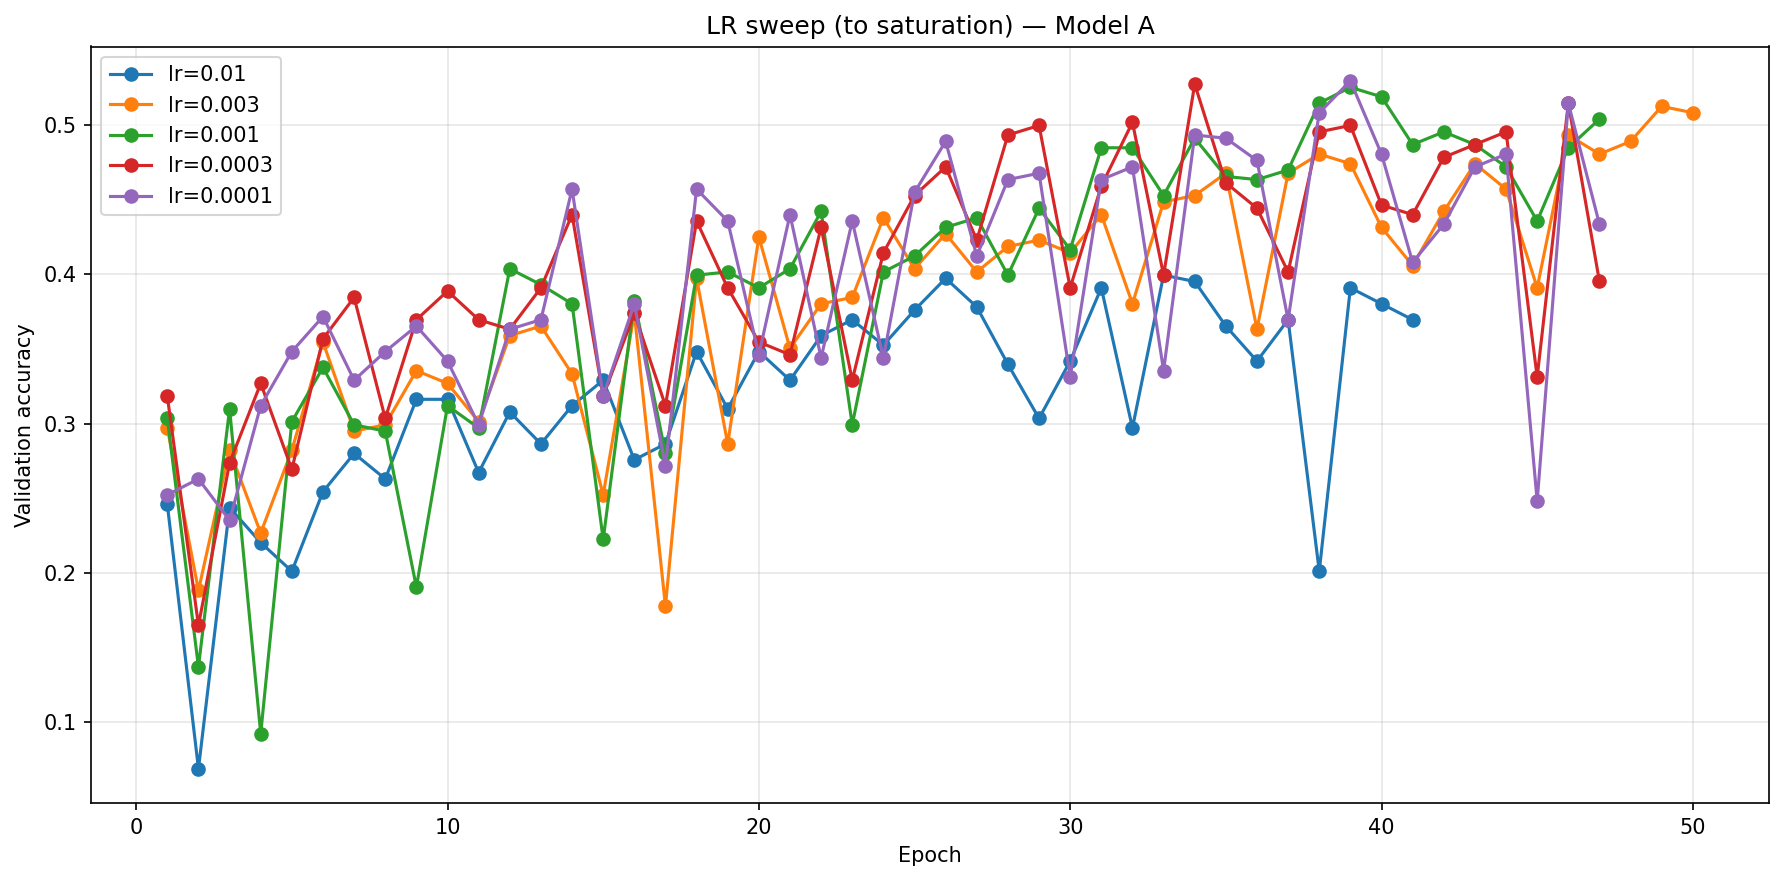

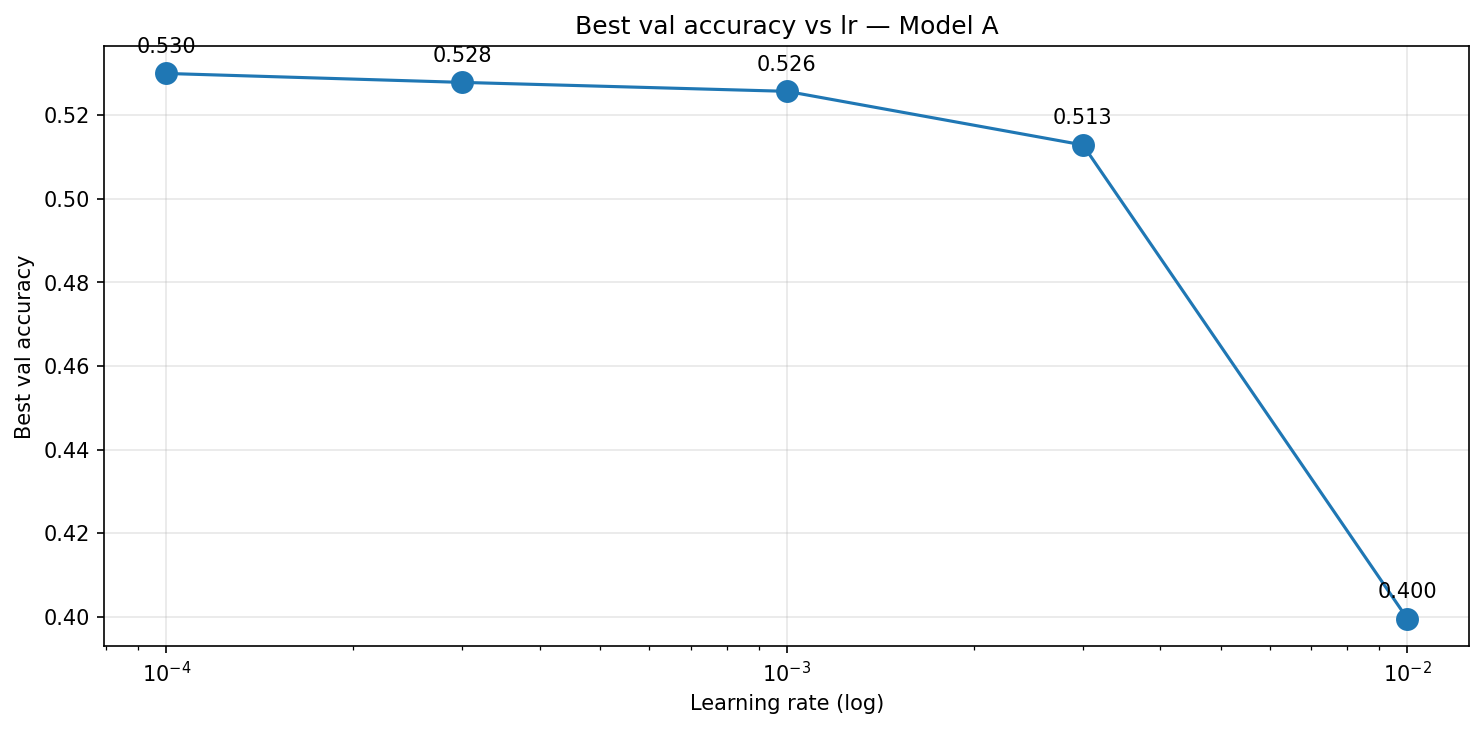

Final training curves:


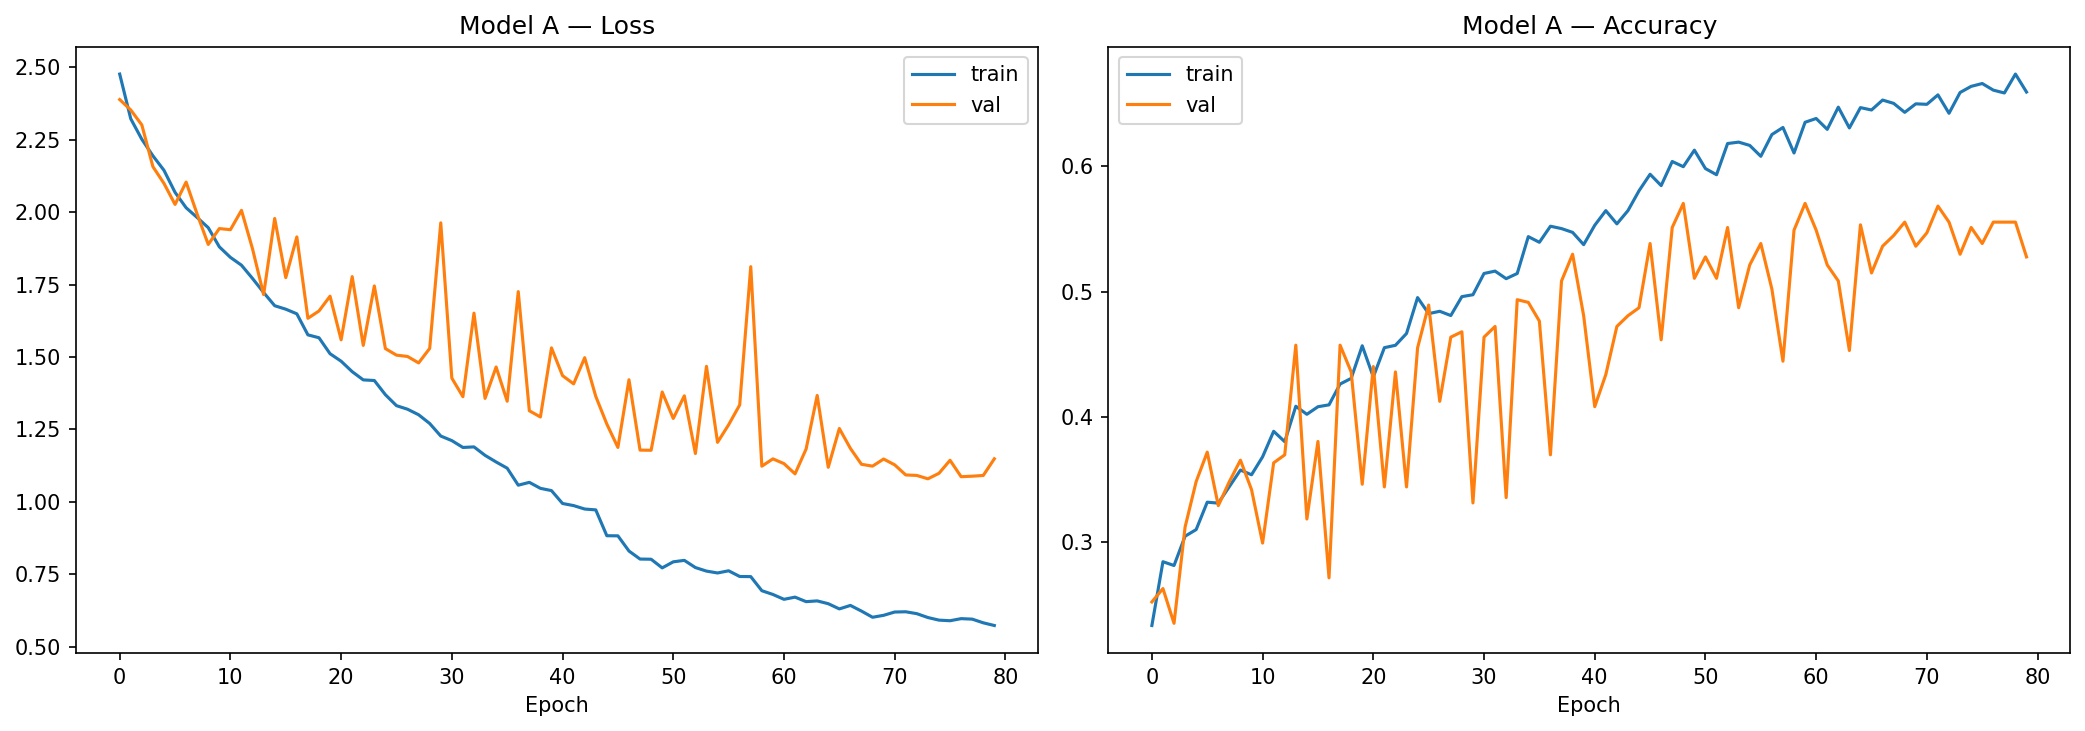

In [8]:
from IPython.display import Image, display
 
print("Learning-rate sweep (to saturation):")
display(Image("../results/kaggleA/lr_sweep_curves_modelA.png"))
display(Image("../results/kaggleA/lr_sweep_best_modelA.png"))
print("Final training curves:")
display(Image("../results/kaggleA/history_modelA.png"))

### Analysis - Model A: Simple3DCNN (from scratch)

**Learning rate tuning (to saturation).**

Ran the sweep on a Kaggle GPU with early stopping, letting each learning rate train to (near-)saturation:

| Learning rate | Best val accuracy (to saturation) |
|---------------|-----------------------------------|
| 1e-4          | **0.530** |
| 3e-4          | 0.528 |
| 1e-3          | 0.526 |
| 3e-3          | (lower) |
| 1e-2          | (lowest) |

Once every rate was trained to saturation, `1e-4` won - it starts slowly but reaches a higher final plateau. The very high learning rates (`1e-2`, `3e-3`) remain the worst, as expected when training from scratch on a small dataset. The final model was therefore trained with `1e-4` to saturation (up to 80 epochs, early stopping on validation loss).

**Overall.**

Final test accuracy **0.558**, weighted F1 **0.554**, macro F1 **0.561**. Top-3 accuracy is **0.910** and Top-5 is **0.963**. Training to saturation with the better learning rate improved the result by ~5 points over the earlier under-trained baseline (0.506). This is a reasonable result for a 3D CNN trained from scratch on only ~3,100 clips. The high Top-3 accuracy shows the model almost always ranks the correct class among its top three guesses.

The macro F1 (0.561) is now essentially equal to the weighted F1 (0.554). In the earlier under-trained run the model had *collapsed* `Point-2f` (predicting almost all `Point` gestures as `Point-1f`), which dragged the weighted F1 far below the macro F1. Training to saturation with `1e-4` fixed this: the model still confuses the two `Point` classes to some extent, but it no longer abandons one of them, so its performance is now balanced across the dominant and minority classes. 

**Where the model still fails (from the confusion matrix):**

- **Point-1f vs Point-2f:** the two static "pointing" gestures are still confused, since they differ only by the number of extended fingers - a fine spatial detail that is hard to read from raw 112×112 pixels.
- **Click / DblClick group:** single vs double click and one vs two fingers remain the hardest distinctions, for the same reason.

**Where the model succeeds:**

- Gestures with large, clear motion over time - the `Throw` directions, `Open-twice`, and the `Zoom` gestures - are handled best. This is precisely what a 3D CNN captures well, in contrast to the static finger-count distinctions it struggles with.

**Summary.**

Even trained to saturation with a properly tuned learning rate, the from-scratch 3D CNN plateaus around 56% - it discriminates gestures well by their *motion* but poorly by fine *static* details such as finger count. This motivates comparing it against (a) the pretrained R(2+1)D-18, whose richer Kinetics-400 features should help on the harder classes, and (b) the landmark-based models, which encode finger geometry explicitly.

## 5. Model B - R(2+1)D-18 (trained on Kaggle)

A 31M-parameter pretrained video model is too slow to fine-tune on local MPS, so
this one trains on Kaggle's free GPU instead - see `notebooks/07_2_modelR(2+1)D.ipynb` for the full self-contained script.

In [9]:
from src.models.r2plus1d import build_r2plus1d

model_b = build_r2plus1d(num_classes=NUM_CLASSES).to(DEVICE)

n_params_b = sum(p.numel() for p in model_b.parameters())
print(f"Model B (R(2+1)D-18) parameters: {n_params_b:,}")

# Forward-pass sanity check with Kinetics normalization
test_ds_b = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=KINETICS_MEAN, std=KINETICS_STD, train=False)
clips_b, labels_b = next(iter(DataLoader(test_ds_b, batch_size=4)))
with torch.no_grad():
    logits_b = model_b(clips_b.to(DEVICE))
print(f"Input shape:  {clips_b.shape}")
print(f"Output shape: {logits_b.shape}")   # expect (B, 13)

Model B (R(2+1)D-18) parameters: 31,306,794
Input shape:  torch.Size([4, 3, 16, 112, 112])
Output shape: torch.Size([4, 13])


## 5a. Load Kaggle Model B results and evaluate

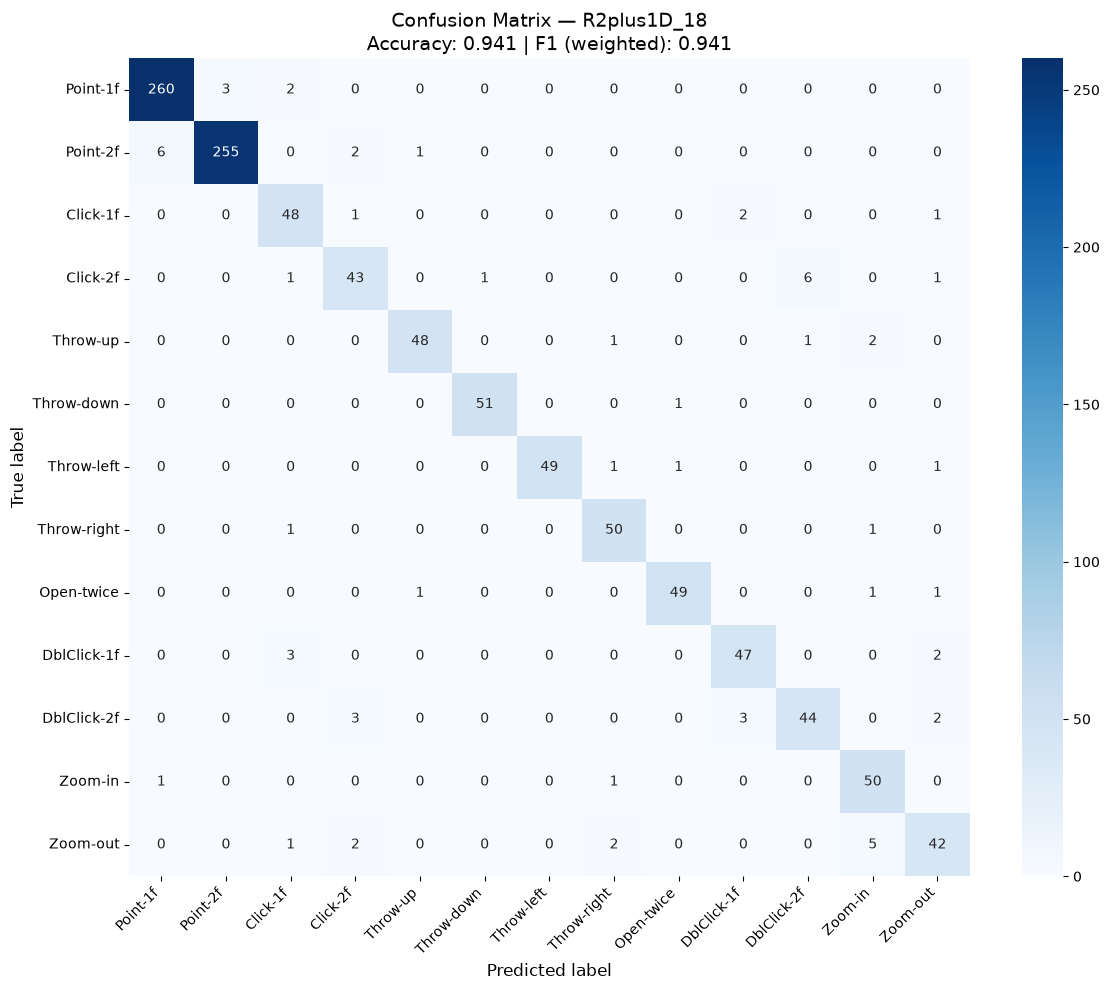

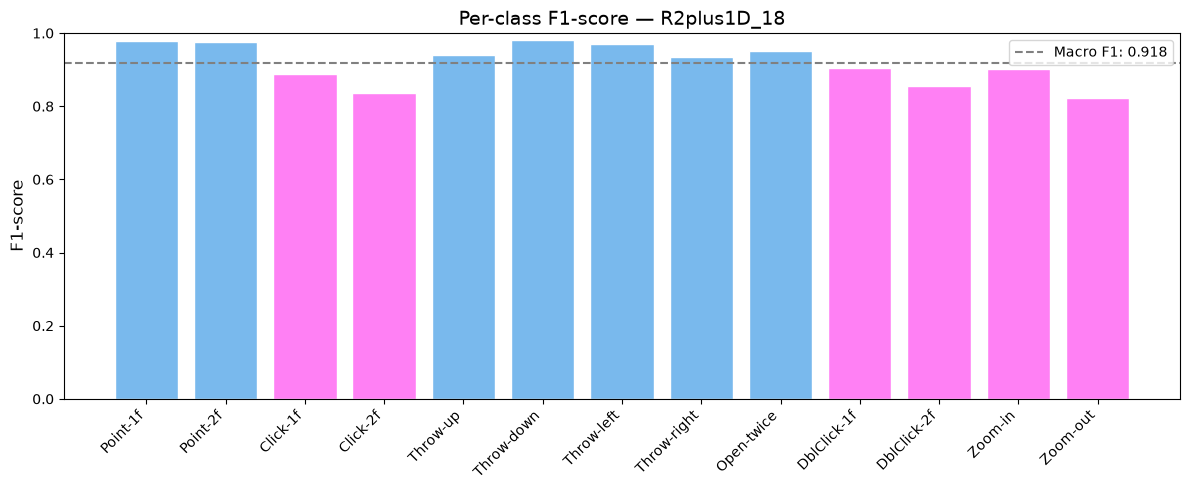


  R2plus1D_18 — Results
  Accuracy:          0.9410
  F1 (weighted):     0.9411
  F1 (macro):        0.9184
  Precision (w):     0.9420
  Recall (w):        0.9410
  Top-3 Accuracy:    0.9882
  Top-5 Accuracy:    0.9955

              precision    recall  f1-score   support

    Point-1f       0.97      0.98      0.98       265
    Point-2f       0.99      0.97      0.98       264
    Click-1f       0.86      0.92      0.89        52
    Click-2f       0.84      0.83      0.83        52
    Throw-up       0.96      0.92      0.94        52
  Throw-down       0.98      0.98      0.98        52
  Throw-left       1.00      0.94      0.97        52
 Throw-right       0.91      0.96      0.93        52
  Open-twice       0.96      0.94      0.95        52
 DblClick-1f       0.90      0.90      0.90        52
 DblClick-2f       0.86      0.85      0.85        52
     Zoom-in       0.85      0.96      0.90        52
    Zoom-out       0.84      0.81      0.82        52

    accuracy        

In [10]:
dataB = np.load("../results/kaggleB/predictions_modelB.npz")
y_true_b, y_pred_b, y_prob_b = dataB['y_true'], dataB['y_pred'], dataB['y_prob']
 
results_b = full_evaluation(
    y_true_b, y_pred_b, "R2plus1D_18",
    save_dir="../results/figures", y_prob=y_prob_b
)
 
with open("../results/kaggleB/r2plus1d_results.json") as f:
    summary_b = json.load(f)
print("\nModel B summary (from Kaggle):")
print(json.dumps(summary_b, indent=2))

## 4b.  Kaggle training curves and sweep plots for Model B

Learning-rate sweep (to saturation):


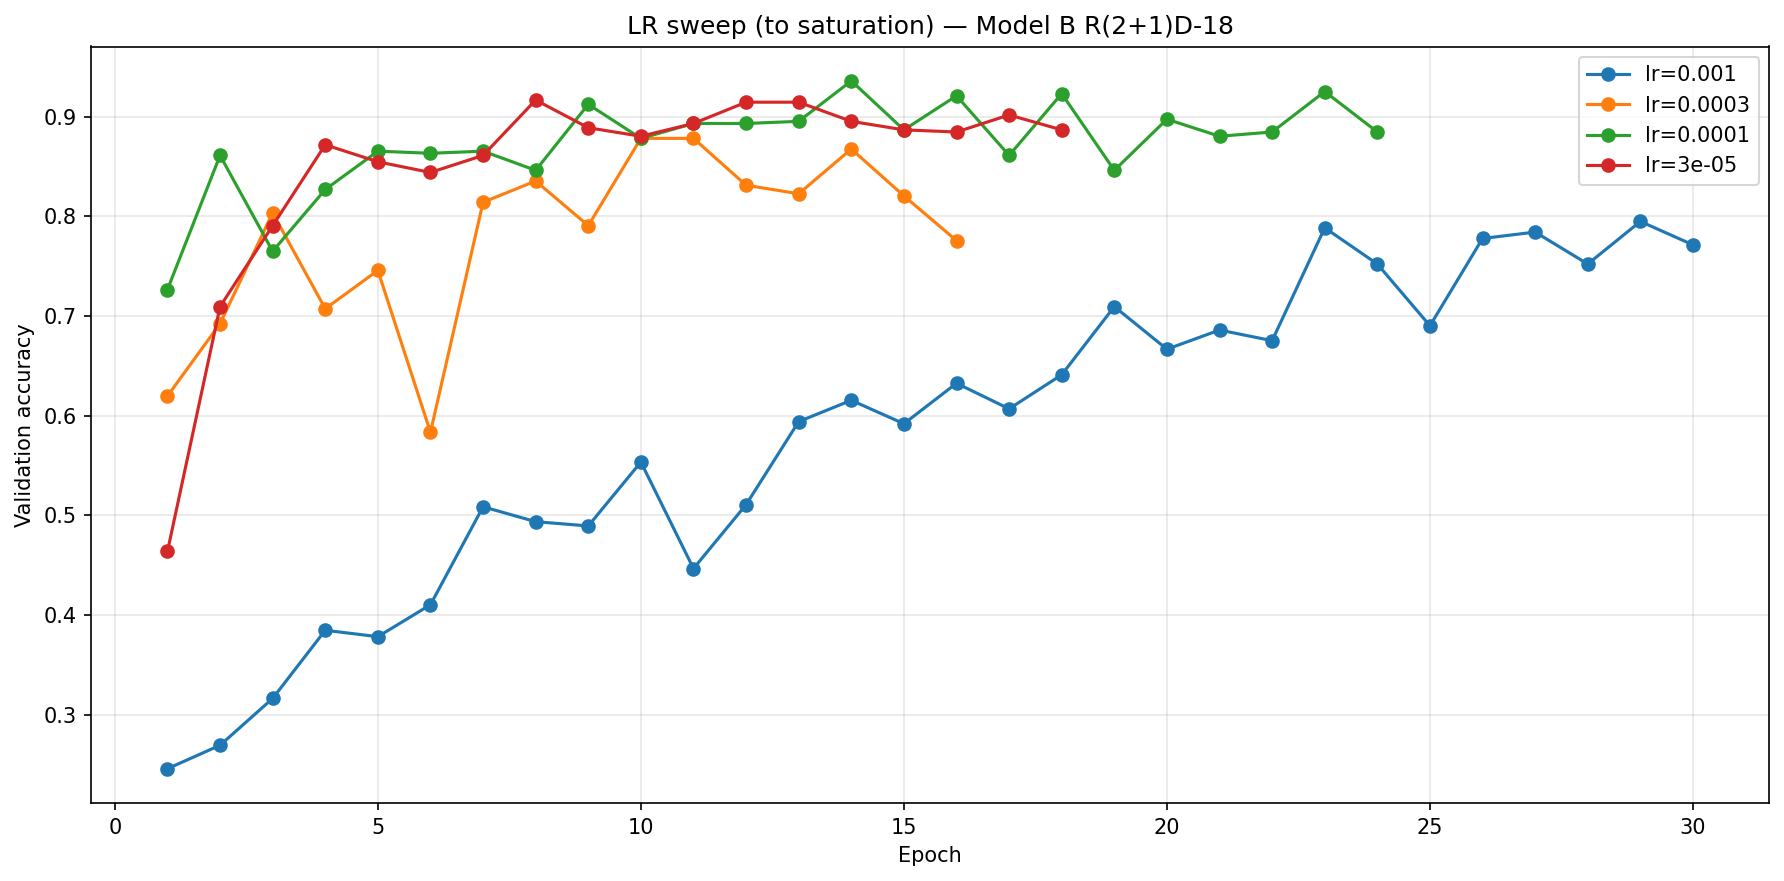

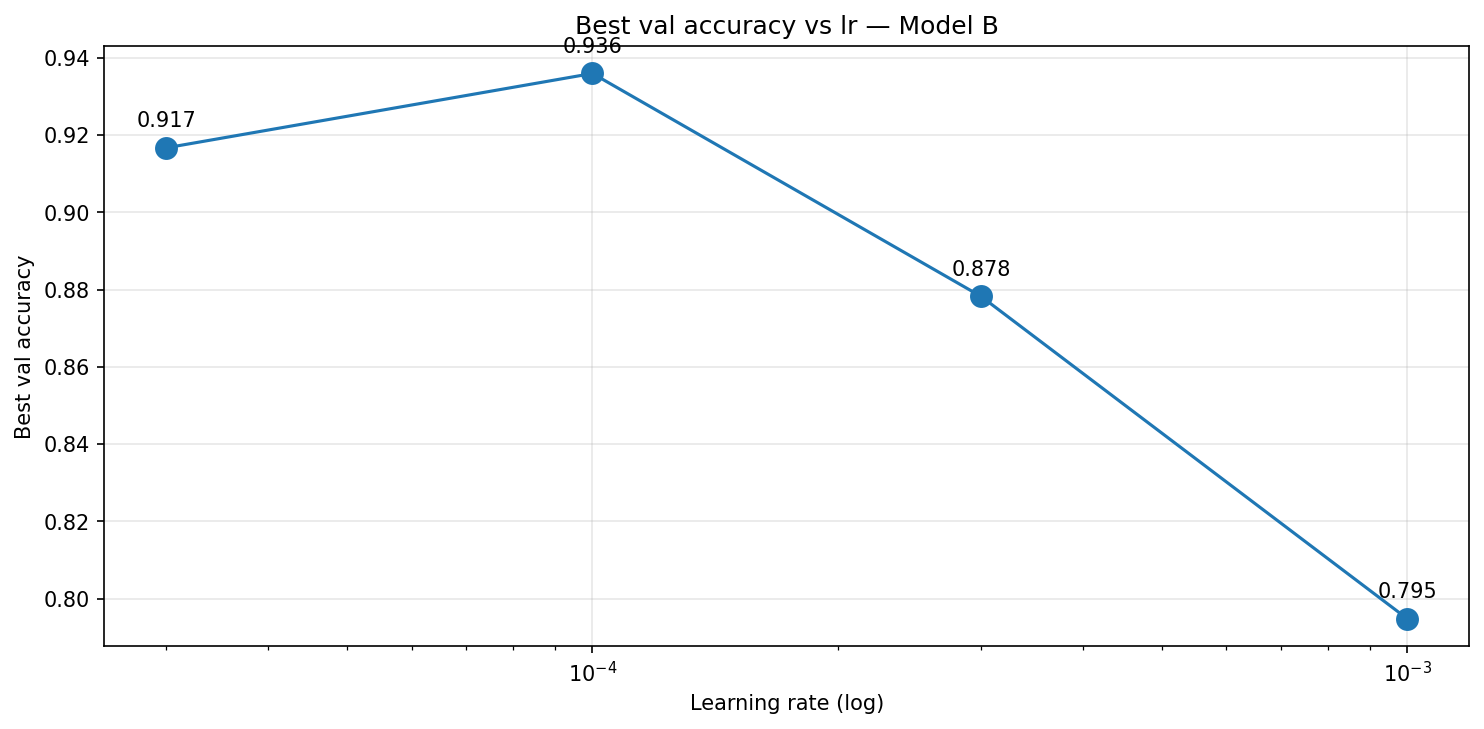

Final training curves:


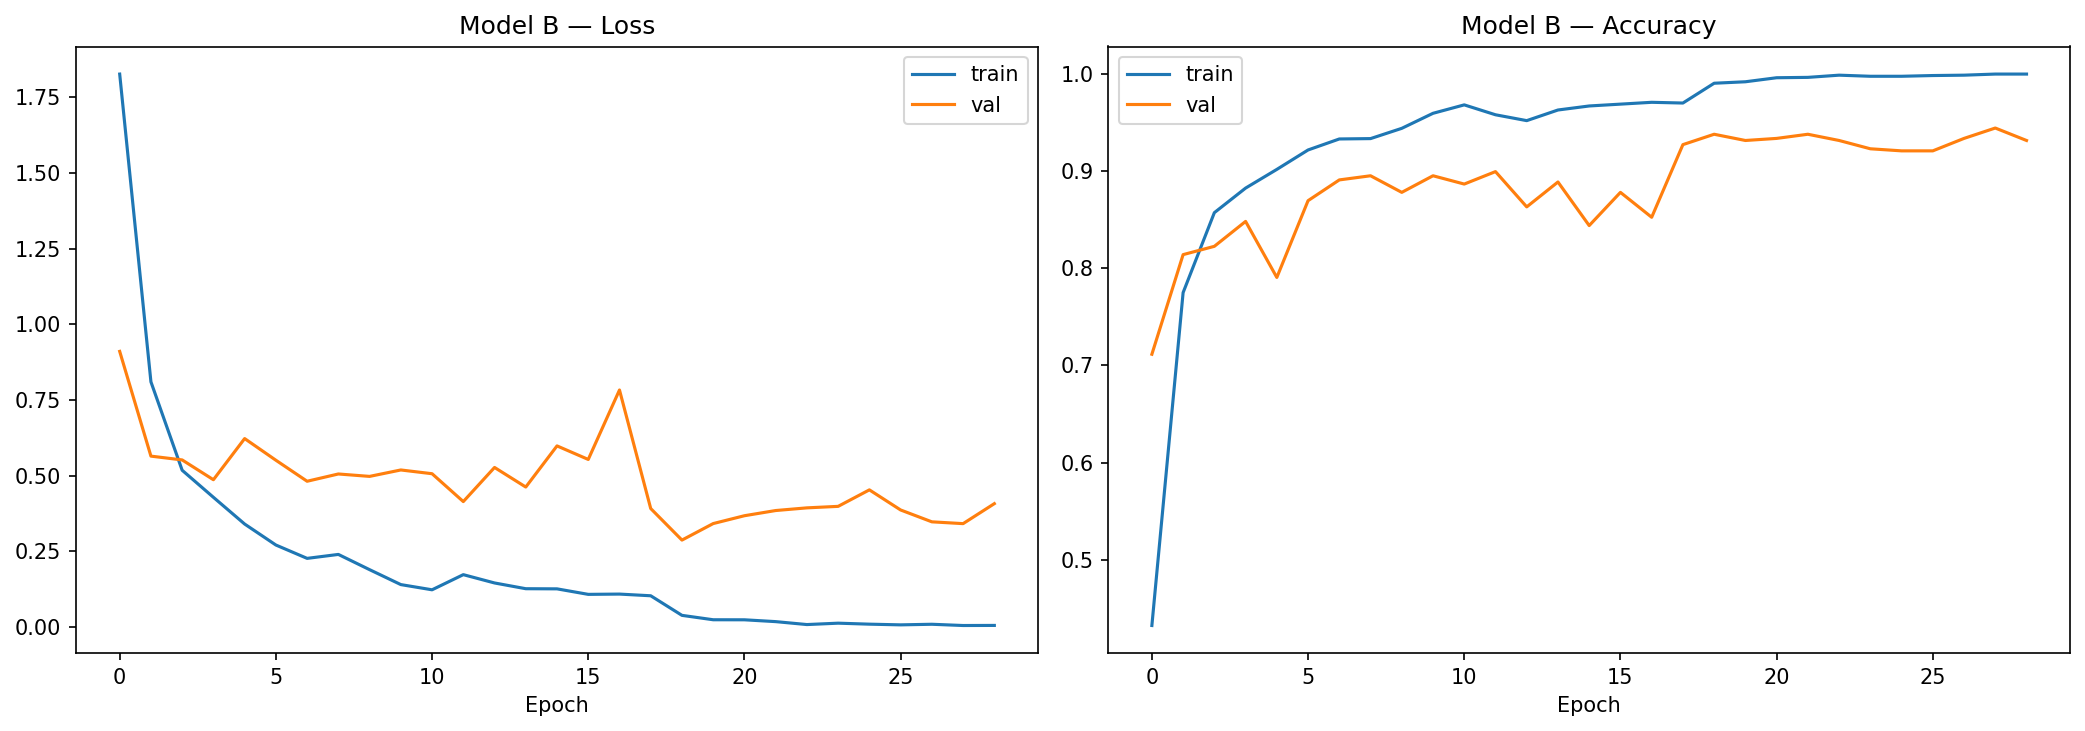

In [11]:
print("Learning-rate sweep (to saturation):")
display(Image("../results/kaggleB/lr_sweep_curves_modelB.png"))
display(Image("../results/kaggleB/lr_sweep_best_modelB.png"))
print("Final training curves:")
display(Image("../results/kaggleB/history_r2plus1d.png"))

## Analysis - Model B: R(2+1)D-18 (pretrained, transfer learning)

**Learning rate tuning (to saturation).**

The learning-rate sweep was re-run on a Kaggle GPU with early stopping so each rate trained to (near-)saturation, using low values appropriate for fine-tuning a pretrained network:

| Learning rate | Best val accuracy (to saturation) |
|---------------|-----------------------------------|
| 1e-4          | **0.936** |
| 3e-5          | 0.917 |
| 3e-4          | 0.878 |
| 1e-3          | 0.795 |

Here `1e-4` won. The pattern is the mirror image of the from-scratch case: for a pretrained model, too *high* a learning rate (`1e-3`) is damaging, because it disturbs the pretrained Kinetics-400 features, while `1e-4` is high enough to adapt them to our task and low enough to preserve them. The final model was trained with `1e-4` to saturation (up to 40 epochs, early stopping on validation loss).

**Overall.**

Final test accuracy **0.941**, weighted F1 **0.941**, macro F1 **0.918**. Top-3 accuracy is **0.988** and Top-5 is **0.996**. This is the best-performing model in the entire project.

The pretrained spatiotemporal features transfer immediately - validation accuracy was already high within the first epochs - and the model then climbs into the mid-0.90s. Because the network is pretrained, it converges quickly; early stopping halts training once validation stops improving.

**Transfer learning solves the hard classes.**

The from-scratch model plateaued at ~56% and confused the static finger-count gestures; R(2+1)D-18 handles them almost perfectly. Both `Point-1f` and `Point-2f` reach F1 **0.98**, and the `Throw` directions likewise reach 0.97–0.98. Even the hardest classes — `Click-2f`, `DblClick-2f`, `Zoom-out` - stay above F1 0.82. No class falls below 0.82, and the **macro F1 of 0.918** shows the model performs evenly across all 13 classes, including the minority ones — a strong result on an imbalanced dataset. The richer pretrained features capture the fine static details (finger count) that pixel-based learning from scratch could not, directly answering the question raised by the Simple3DCNN analysis.

**Remaining errors.**

The few remaining confusions are among the subtle click-type and zoom gestures (e.g. `Click-2f` / `DblClick-2f`, `Zoom-out`), but they are minor - every class is now handled well.

**Summary.**

Transfer learning is decisive on this small dataset: R(2+1)D-18 raises accuracy from ~56% (from scratch) to **94.1%**, and specifically fixes the finger-count and click-type distinctions that pixel-based learning from scratch could not. It is the strongest model in the project. The landmark-based BiLSTM reaches comparable-to-lower accuracy (0.877) with roughly 50× fewer parameters - a trade-off between raw accuracy and model compactness explored in the final comparison.

## 9. Scratch vs. pretrained comparison

How much transfer learning actually buys over the from-scratch 3D CNN — accuracy,
F1, and inference speed side by side, using the shared `compare_models()`.

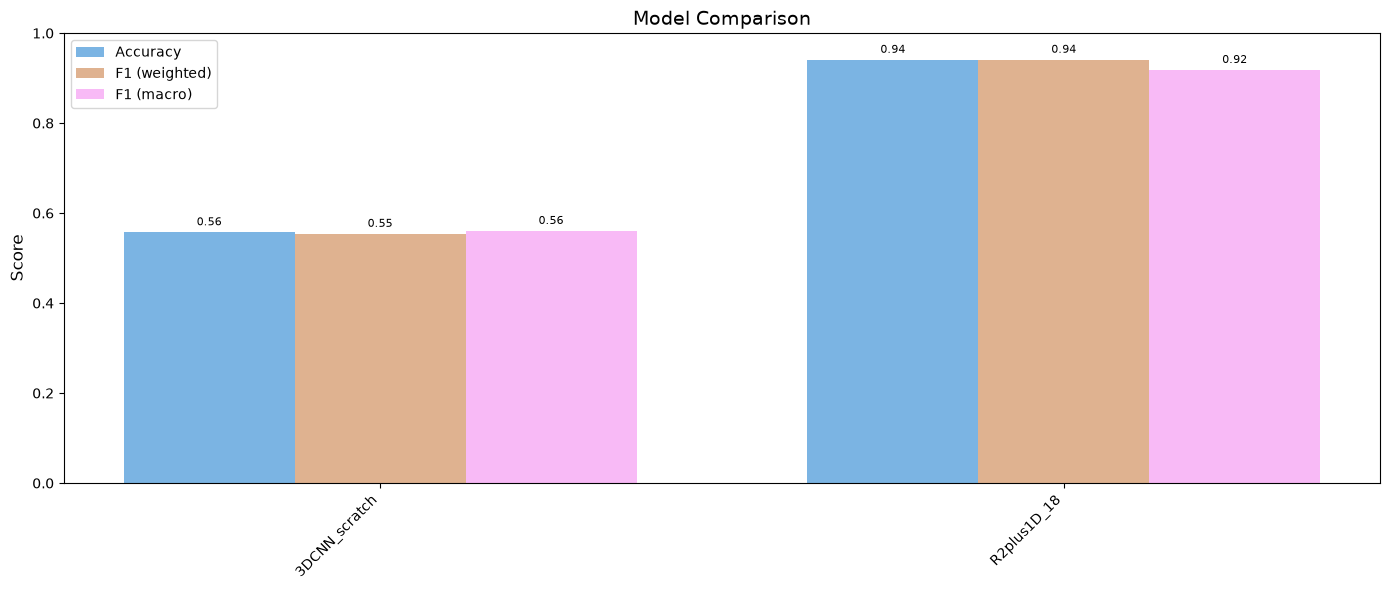


  FINAL MODEL COMPARISON
  Model                       Accuracy     F1 (w)     F1 (m)
  -------------------------------------------------------
  R2plus1D_18                   0.9410     0.9411     0.9184
  3DCNN_scratch                 0.5577     0.5542     0.5606



In [12]:
from src.evaluation.metrics import compare_models
all_results = [results_a, results_b]
compare_models(all_results, save_dir="../results/figures")

In [13]:
# Add parameters number to json
from src.models.cnn3d import Simple3DCNN
from src.models.r2plus1d import build_r2plus1d

a = Simple3DCNN(num_classes=13)
b = build_r2plus1d(num_classes=13)
print("Simple3DCNN parameters:", sum(p.numel() for p in a.parameters()))
print("R(2+1)D-18 parameters:", sum(p.numel() for p in b.parameters()))

Simple3DCNN parameters: 1199821
R(2+1)D-18 parameters: 31306794
